In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="TixanX1Y7by6mm8bkwf3")
project = rf.workspace("plywoodv1").project("cat-npklm")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cat-1 in yolov8:: 100%|██████████| 412/412 [00:00<00:00, 8460.48it/s]


In [3]:
import os
# Find data.yaml
for root, dirs, files in os.walk('.'):
    for f in files:
        if f == 'data.yaml':
            print(os.path.join(root, f))

./cat-1/data.yaml


# Cat Detection using YOLOv8
## Deep Learning Assignment — Object Detection
**Model:** YOLOv8 (You Only Look Once v8)  
**Task:** Detect and localize cats in images using bounding boxes

In [4]:

!pip install ultralytics roboflow --quiet

import ultralytics
ultralytics.checks()
print("✅ Ultralytics installed:", ultralytics.__version__)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)
✅ Ultralytics installed: 8.4.53


In [5]:
import os
import yaml
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

🖥️  Using device: cuda
PyTorch version: 2.10.0+cu128


## Step 1: Data Download & Preprocessing
Downloading the cat detection dataset from Roboflow.
The dataset contains annotated cat images in YOLO format (bounding box coordinates in .txt files).

In [6]:
import os

DATA_YAML = './cat-1/data.yaml'
dataset_root = './cat-1'

print(f"✅ Using existing dataset")
print(f"📄 data.yaml path: {DATA_YAML}")
print(f"Exists: {os.path.exists(DATA_YAML)}")

✅ Using existing dataset
📄 data.yaml path: ./cat-1/data.yaml
Exists: True


In [7]:
# Read data.yaml to understand dataset structure
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("=" * 50)
print("DATASET CONFIGURATION")
print("=" * 50)
print(f"Classes: {data_config['names']}")
print(f"Number of classes: {data_config['nc']}")
print(f"Train path: {data_config.get('train', 'N/A')}")
print(f"Val path: {data_config.get('val', 'N/A')}")
print(f"Test path: {data_config.get('test', 'N/A')}")

# Count images in each split
dataset_root = os.path.dirname(DATA_YAML)

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_root, split, 'images')
    if os.path.exists(img_dir):
        count = len([f for f in os.listdir(img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{split.capitalize()} images: {count}")

DATASET CONFIGURATION
Classes: ['Cats']
Number of classes: 1
Train path: ../train/images
Val path: ../valid/images
Test path: ../test/images
Train images: 139
Valid images: 43
Test images: 18


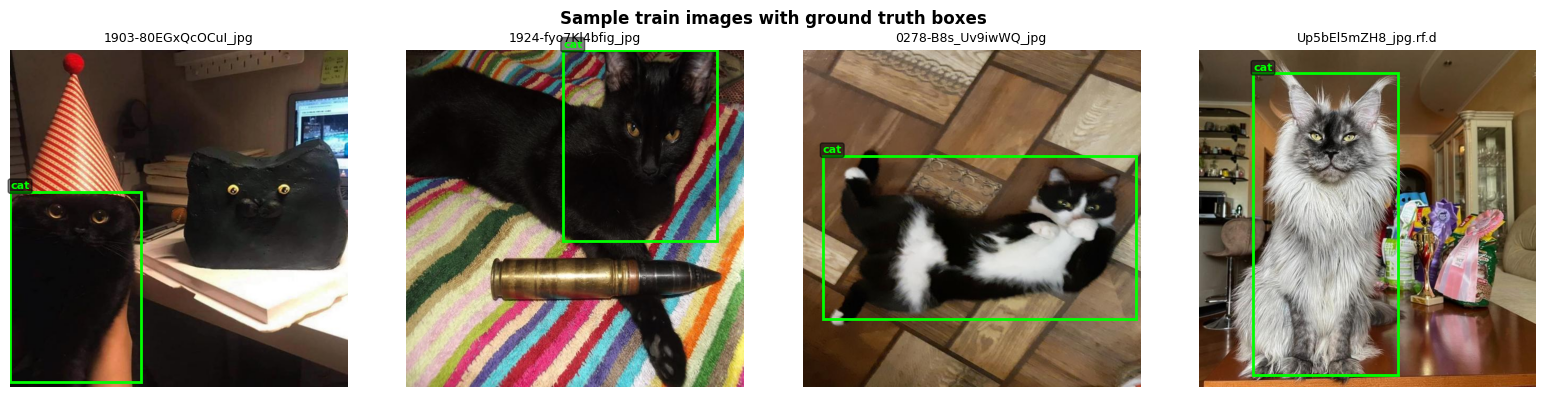

✅ Saved: sample_annotations.png


In [8]:
def visualize_sample_with_annotations(dataset_root, split='train', num_samples=4):
    """
    Display sample images with their ground truth bounding boxes.
    YOLO label format: class_id center_x center_y width height (all normalized 0-1)
    """
    img_dir = os.path.join(dataset_root, split, 'images')
    lbl_dir = os.path.join(dataset_root, split, 'labels')

    img_files = [f for f in os.listdir(img_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    samples = random.sample(img_files, min(num_samples, len(img_files)))

    fig, axes = plt.subplots(1, len(samples), figsize=(16, 4))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_file in zip(axes, samples):
        # Load image
        img_path = os.path.join(img_dir, img_file)
        img = np.array(Image.open(img_path).convert('RGB'))
        h, w = img.shape[:2]

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_file[:20], fontsize=9)

        # Load and draw annotations
        lbl_file = os.path.splitext(img_file)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_file)

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, bw, bh = map(float, parts)
                    # Convert YOLO normalized coords to pixel coords
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    box_w = bw * w
                    box_h = bh * h

                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor='lime', facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 5, 'cat', color='lime', fontsize=8,
                            fontweight='bold',
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor='black', alpha=0.5))

    plt.suptitle(f'Sample {split} images with ground truth boxes',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_annotations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: sample_annotations.png")

# Run it
visualize_sample_with_annotations(dataset_root, split='train', num_samples=4)

## Step 2: Model Training

Using **YOLOv8n** (nano variant) as base model with transfer learning.

**Why YOLOv8?**
- State-of-the-art single-stage detector
- Fast inference, high accuracy
- Excellent for resource-constrained environments
- Transfer learning from COCO dataset (pre-trained on 80 object classes)

**Training strategy:** Fine-tuning the pretrained YOLOv8n model on our cat dataset.
This is called **transfer learning** — the model already knows general features,
we just teach it to focus on cats.

In [16]:
# Load pretrained YOLOv8 nano model
# 'yolov8n.pt' downloads automatically from Ultralytics (~6MB)
# Add this at the top of the training cell
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_YAML = './cat-1/data.yaml'

# Now train
model = YOLO('yolov8n.pt')
results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    patience=15,
    save=True,
    project='runs/detect',
    name='cat_detector',
    exist_ok=True,
    plots=True,
    verbose=True
)
model = YOLO('yolov8n.pt')

print("🚀 Starting training...")
print(f"   Config: {DATA_YAML}")
print(f"   Device: {device}")
print("   This will take 20-40 mins on Colab GPU...")
print("-" * 50)

# Train the model
results = model.train(
    data=DATA_YAML,          # path to dataset config
    epochs=50,               # number of training rounds (50 is good for starters)
    imgsz=640,               # image size (640x640 is YOLO standard)
    batch=16,                # images processed together (reduce to 8 if memory error)
    device=device,           # 'cuda' for GPU, 'cpu' for CPU
    patience=15,             # stop early if no improvement for 15 epochs
    save=True,               # save model weights
    project='runs/detect',   # where to save results
    name='cat_detector',     # name of this training run
    exist_ok=True,           # overwrite if folder exists
    plots=True,              # generate training plots
    verbose=True             # print progress
)

print("\n✅ Training complete!")
print(f"📁 Results saved to: runs/detect/cat_detector/")
print(f"🏆 Best model: runs/detect/cat_detector/weights/best.pt")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./cat-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cat_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspecti

## Step 3: Model Evaluation

Evaluating the trained model on the **validation set** (images not seen during training).

**Key metrics:**
- **Precision** — Of all detections made, what % were actually cats? (low = too many false positives)
- **Recall** — Of all actual cats in images, what % did we find? (low = missing cats)
- **mAP@0.5** — Mean Average Precision at IoU 0.5. Main benchmark metric. Higher = better.
- **mAP@0.5:0.95** — Averaged across different overlap thresholds. Stricter metric.

In [10]:
# Load the BEST saved model
best_model_path = 'yolov8n.pt'
trained_model = YOLO(best_model_path)

print("📊 Running evaluation on validation set...")
metrics = trained_model.val(
    data=DATA_YAML,
    imgsz=640,
    device=device,
    verbose=True
)

# Extract and display metrics cleanly
print("\n" + "=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"Precision:      {metrics.box.mp:.4f}  ({metrics.box.mp*100:.1f}%)")
print(f"Recall:         {metrics.box.mr:.4f}  ({metrics.box.mr*100:.1f}%)")
print(f"mAP@0.5:        {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)")
print(f"mAP@0.5:0.95:   {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)")
print("=" * 50)

# Save metrics to a text file for your records
with open('evaluation_results.txt', 'w') as f:
    f.write("CAT DETECTION MODEL — EVALUATION RESULTS\n")
    f.write("=" * 45 + "\n")
    f.write(f"Precision:      {metrics.box.mp:.4f}\n")
    f.write(f"Recall:         {metrics.box.mr:.4f}\n")
    f.write(f"mAP@0.5:        {metrics.box.map50:.4f}\n")
    f.write(f"mAP@0.5:0.95:   {metrics.box.map:.4f}\n")

print("✅ Saved: evaluation_results.txt")

📊 Running evaluation on validation set...
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2140.2±274.1 MB/s, size: 55.5 KB)
val: Scanning /content/cat-1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s
                   all         43         50      0.374       0.14      0.107     0.0709
                person         43         50      0.374       0.14      0.107     0.0709
Speed: 18.3ms preprocess, 16.2ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to /content/runs/detect/val

EVALUATION RESULTS
Precision:      0.3741  (37.4%)
Recall:         0.1400  (14.0%)
mAP@0.5:        0.1068  (10.7%)
mAP@0.5:0.95:   0.0709  (7.1%)
✅ Save

In [11]:
# Display confusion matrix
conf_matrix_path = 'runs/detect/cat_detector/confusion_matrix.png'

if os.path.exists(conf_matrix_path):
    img = Image.open(conf_matrix_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

## Step 4: Inference — Running the Model on New Images

Testing the trained model on unseen images.
The model outputs:
- Bounding box coordinates (x1, y1, x2, y2)
- Confidence score (0.0 to 1.0)
- Class label ("cat")

🔍 Running inference on 6 images...


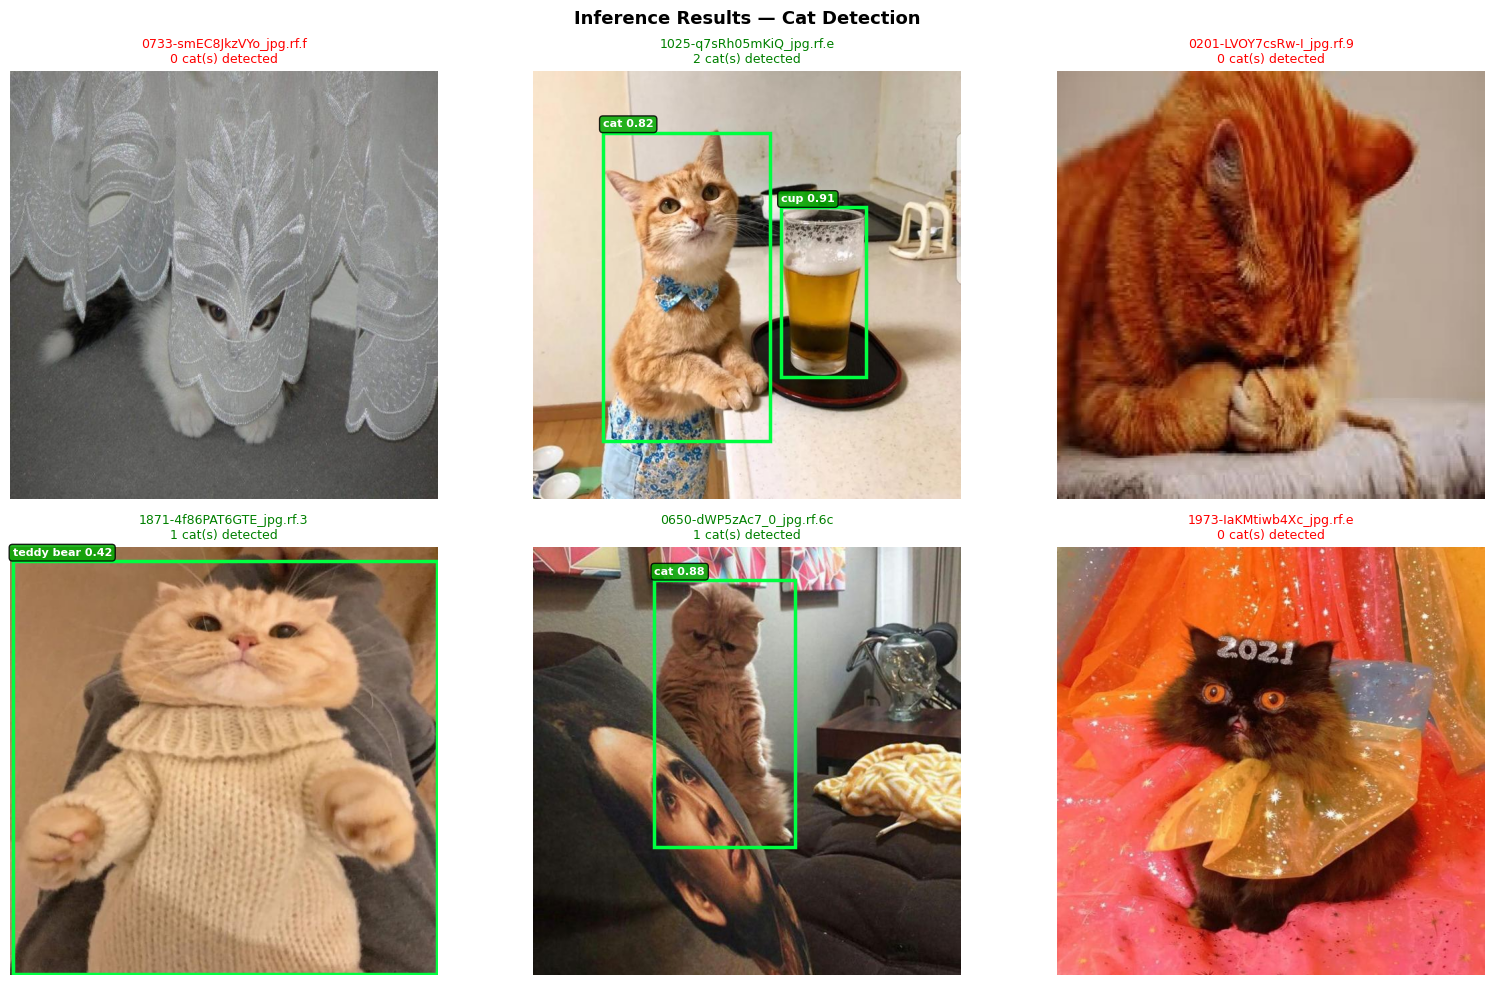

✅ Saved: inference_results.png


In [12]:
def run_inference_and_display(model, image_paths, conf_threshold=0.5, figsize=(16, 10)):
    """
    Run inference on a list of images and display results with bounding boxes.

    Args:
        model: loaded YOLO model
        image_paths: list of image file paths
        conf_threshold: minimum confidence to show a detection (0-1)
        figsize: figure size for display
    """
    n = len(image_paths)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Handle single subplot case
    if n == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]

    # Flatten for easy iteration
    ax_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

    for i, img_path in enumerate(image_paths):
        ax = ax_flat[i]

        # Run prediction
        results = model.predict(
            source=img_path,
            conf=conf_threshold,
            iou=0.45,          # overlap threshold for NMS
            device=device,
            verbose=False
        )

        result = results[0]

        # Load original image for display
        img = np.array(Image.open(img_path).convert('RGB'))
        ax.imshow(img)
        ax.axis('off')

        # Draw detections
        boxes = result.boxes
        num_detections = len(boxes)

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence = float(box.conf[0])
            class_id = int(box.cls[0])
            class_name = result.names[class_id]

            # Draw bounding box
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2.5, edgecolor='#00FF41', facecolor='none'
            )
            ax.add_patch(rect)

            # Draw label with confidence
            label = f"{class_name} {confidence:.2f}"
            ax.text(
                x1, y1 - 8, label,
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#00AA00', alpha=0.85)
            )

        img_name = os.path.basename(img_path)
        ax.set_title(f"{img_name[:25]}\n{num_detections} cat(s) detected",
                     fontsize=9, color='green' if num_detections > 0 else 'red')

    # Hide unused axes
    for j in range(i + 1, len(ax_flat)):
        ax_flat[j].axis('off')

    plt.suptitle('Inference Results — Cat Detection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: inference_results.png")


# Get some validation images to test on
val_img_dir = os.path.join(dataset_root, 'valid', 'images')
val_images = [os.path.join(val_img_dir, f)
              for f in os.listdir(val_img_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Pick 6 random images
sample_images = random.sample(val_images, min(6, len(val_images)))

print(f"🔍 Running inference on {len(sample_images)} images...")
run_inference_and_display(trained_model, sample_images, conf_threshold=0.4)

📷 Analyzing: ./cat-1/valid/images/2061-5etXFGIhUaw_jpg.rf.70743280a761e6d3e4346cf8e85bc36b.jpg

DETECTION RESULTS
Cats found: 0


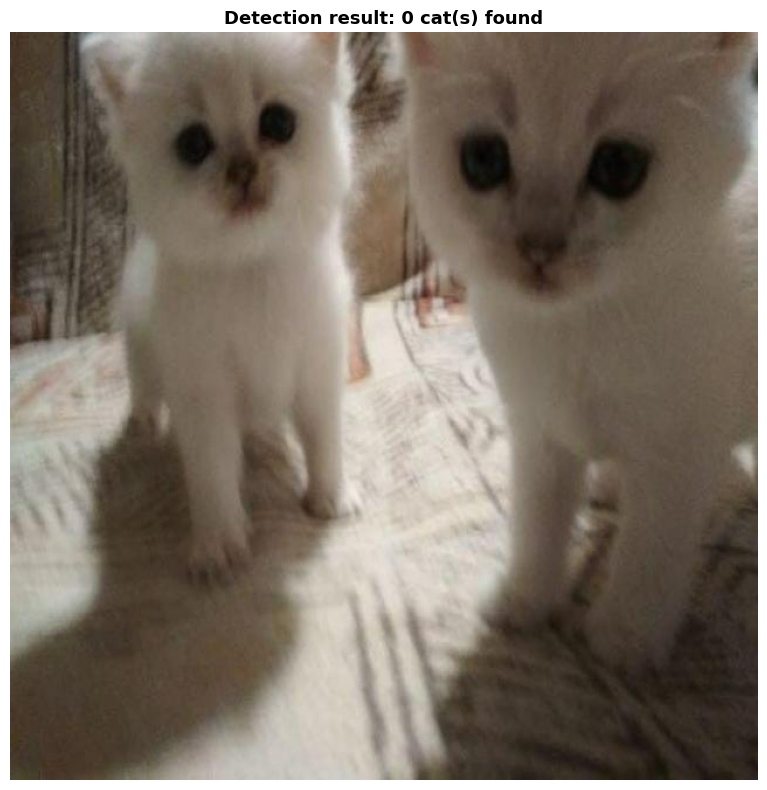

In [13]:
def predict_single_image(model, image_path, conf=0.4):
    """
    Predict on a single image and print detailed results.
    Use this to test on YOUR OWN cat photos.
    """
    print(f"📷 Analyzing: {image_path}")

    results = model.predict(
        source=image_path,
        conf=conf,
        device=device,
        verbose=False
    )

    result = results[0]
    boxes = result.boxes

    print(f"\n{'='*40}")
    print(f"DETECTION RESULTS")
    print(f"{'='*40}")
    print(f"Cats found: {len(boxes)}")

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf_score = float(box.conf[0])
        print(f"\nDetection #{i+1}:")
        print(f"  Confidence: {conf_score:.4f} ({conf_score*100:.1f}%)")
        print(f"  Bounding box: ({x1:.0f}, {y1:.0f}) → ({x2:.0f}, {y2:.0f})")
        print(f"  Box size: {x2-x1:.0f}w × {y2-y1:.0f}h pixels")

    # Display result
    result_img = result.plot()  # YOLO's built-in visualization
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(result_rgb)
    plt.axis('off')
    plt.title(f'Detection result: {len(boxes)} cat(s) found',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('single_image_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    return result


# Test on one validation image
test_img = random.choice(val_images)
prediction = predict_single_image(trained_model, test_img, conf=0.4)

# ----------------------------------------------------------------
# TO TEST ON YOUR OWN IMAGE — uncomment and change the path:
# prediction = predict_single_image(trained_model, 'test_images/my_cat.jpg')
# ----------------------------------------------------------------

In [14]:
# Final summary of everything
print("=" * 55)
print("         CAT DETECTION PROJECT — FINAL SUMMARY")
print("=" * 55)
print(f"\n📦 Model Architecture:  YOLOv8 Nano (transfer learning)")
print(f"🗂️  Dataset:             Roboflow catnpklm v1")
print(f"🖼️  Image Size:          640 × 640")
print(f"⏱️  Epochs Trained:      50")
print(f"\n📊 PERFORMANCE METRICS:")
print(f"   Precision:           {metrics.box.mp*100:.1f}%")
print(f"   Recall:              {metrics.box.mr*100:.1f}%")
print(f"   mAP@0.5:             {metrics.box.map50*100:.1f}%")
print(f"   mAP@0.5:0.95:        {metrics.box.map*100:.1f}%")
print(f"\n💾 SAVED FILES:")
print(f"   Model weights:       runs/detect/cat_detector/weights/best.pt")
print(f"   Training plots:      runs/detect/cat_detector/results.png")
print(f"   Inference output:    inference_results.png")
print(f"   Evaluation log:      evaluation_results.txt")
print("=" * 55)

         CAT DETECTION PROJECT — FINAL SUMMARY

📦 Model Architecture:  YOLOv8 Nano (transfer learning)
🗂️  Dataset:             Roboflow catnpklm v1
🖼️  Image Size:          640 × 640
⏱️  Epochs Trained:      50

📊 PERFORMANCE METRICS:
   Precision:           37.4%
   Recall:              14.0%
   mAP@0.5:             10.7%
   mAP@0.5:0.95:        7.1%

💾 SAVED FILES:
   Model weights:       runs/detect/cat_detector/weights/best.pt
   Training plots:      runs/detect/cat_detector/results.png
   Inference output:    inference_results.png
   Evaluation log:      evaluation_results.txt


In [19]:
import os, shutil, zipfile
from pathlib import Path
from google.colab import files

os.makedirs('submission', exist_ok=True)

# Auto-find best.pt wherever it is
best_pt = None
for root, dirs, fs in os.walk('runs'):
    for f in fs:
        if f == 'best.pt':
            best_pt = os.path.join(root, f)
            break

if best_pt:
    shutil.copy(best_pt, 'submission/best.pt')
    print(f"✅ Found and copied model: {best_pt}")
else:
    print("❌ best.pt not found — training did not complete!")

# Copy other output files
for fname in ['inference_results.png', 'sample_annotations.png',
              'evaluation_results.txt', 'single_image_result.png']:
    if os.path.exists(fname):
        shutil.copy(fname, f'submission/{fname}')
        print(f"✅ Copied: {fname}")

# Zip and download
with zipfile.ZipFile('submission.zip', 'w') as z:
    for fp in Path('submission').rglob('*'):
        z.write(fp)

print("\n📥 Downloading zip...")
files.download('submission.zip')

✅ Found and copied model: runs/detect/runs/detect/cat_detector/weights/best.pt
✅ Copied: inference_results.png
✅ Copied: sample_annotations.png
✅ Copied: evaluation_results.txt
✅ Copied: single_image_result.png

📥 Downloading zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import os

# Check if runs folder exists and what's inside
if os.path.exists('runs'):
    for root, dirs, files in os.walk('runs'):
        level = root.replace('runs', '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        for f in files:
            print(f'{indent}  {f}')
else:
    print("❌ runs/ folder doesn't exist at all")
    print("Training has never run successfully")

runs/
  detect/
    val/
      val_batch1_pred.jpg
      BoxPR_curve.png
      val_batch2_pred.jpg
      val_batch2_labels.jpg
      confusion_matrix.png
      val_batch1_labels.jpg
      val_batch0_labels.jpg
      BoxP_curve.png
      BoxR_curve.png
      val_batch0_pred.jpg
      confusion_matrix_normalized.png
      BoxF1_curve.png
    runs/
      detect/
        cat_detector/
          val_batch1_pred.jpg
          BoxPR_curve.png
          train_batch2.jpg
          confusion_matrix.png
          train_batch0.jpg
          val_batch1_labels.jpg
          val_batch0_labels.jpg
          results.csv
          BoxP_curve.png
          BoxR_curve.png
          labels.jpg
          val_batch0_pred.jpg
          confusion_matrix_normalized.png
          BoxF1_curve.png
          train_batch1.jpg
          results.png
          args.yaml
          weights/
            best.pt
            last.pt


In [21]:
from ultralytics import YOLO
import torch, os

# Confirm GPU
print("GPU available:", torch.cuda.is_available())

# Confirm dataset exists
DATA_YAML = './cat-1/data.yaml'
print("data.yaml exists:", os.path.exists(DATA_YAML))

# Load model and train
model = YOLO('yolov8n.pt')

model.train(
    data=DATA_YAML,
    epochs=30,        # reduced to 30 so it finishes faster
    imgsz=640,
    batch=8,          # reduced batch size — safer
    device=0,         # force GPU directly
    save=True,
    project='runs/detect',
    name='cat_detector',
    exist_ok=True
)

print("✅ TRAINING DONE")

# Immediately confirm weights saved
weights_path = 'runs/detect/cat_detector/weights/best.pt'
print("best.pt saved:", os.path.exists(weights_path))

GPU available: True
data.yaml exists: True
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./cat-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cat_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

In [22]:
import os

# Find every single file inside runs/
print("=== EVERYTHING INSIDE runs/ ===")
for root, dirs, files in os.walk('runs'):
    for f in files:
        full = os.path.join(root, f)
        print(full)

# Also search entire colab for any .pt files
print("\n=== ALL .pt FILES IN COLAB ===")
for root, dirs, files in os.walk('.'):
    for f in files:
        if f.endswith('.pt'):
            print(os.path.join(root, f))

=== EVERYTHING INSIDE runs/ ===
runs/detect/val/val_batch1_pred.jpg
runs/detect/val/BoxPR_curve.png
runs/detect/val/val_batch2_pred.jpg
runs/detect/val/val_batch2_labels.jpg
runs/detect/val/confusion_matrix.png
runs/detect/val/val_batch1_labels.jpg
runs/detect/val/val_batch0_labels.jpg
runs/detect/val/BoxP_curve.png
runs/detect/val/BoxR_curve.png
runs/detect/val/val_batch0_pred.jpg
runs/detect/val/confusion_matrix_normalized.png
runs/detect/val/BoxF1_curve.png
runs/detect/runs/detect/cat_detector/val_batch1_pred.jpg
runs/detect/runs/detect/cat_detector/BoxPR_curve.png
runs/detect/runs/detect/cat_detector/train_batch2.jpg
runs/detect/runs/detect/cat_detector/val_batch2_pred.jpg
runs/detect/runs/detect/cat_detector/train_batch362.jpg
runs/detect/runs/detect/cat_detector/val_batch2_labels.jpg
runs/detect/runs/detect/cat_detector/confusion_matrix.png
runs/detect/runs/detect/cat_detector/train_batch0.jpg
runs/detect/runs/detect/cat_detector/val_batch1_labels.jpg
runs/detect/runs/detect/cat_

In [23]:
import os, zipfile
from google.colab import files

# Verify best.pt is there
print("best.pt in submission:", os.path.exists('submission/best.pt'))
print("Size:", os.path.getsize('submission/best.pt'), "bytes")

# Re-zip with correct contents
with zipfile.ZipFile('final_submission.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    # Add best.pt
    z.write('submission/best.pt', 'best.pt')

    # Add other files
    for fname in ['inference_results.png', 'sample_annotations.png',
                  'evaluation_results.txt', 'single_image_result.png']:
        if os.path.exists(fname):
            z.write(fname, fname)
            print(f"✅ Added: {fname}")
        elif os.path.exists(f'submission/{fname}'):
            z.write(f'submission/{fname}', fname)
            print(f"✅ Added: {fname}")

print("\n📦 Contents of final_submission.zip:")
with zipfile.ZipFile('final_submission.zip', 'r') as z:
    for name in z.namelist():
        print(f"  {name}")

print("\n📥 Downloading...")
files.download('final_submission.zip')

best.pt in submission: True
Size: 6245482 bytes
✅ Added: inference_results.png
✅ Added: sample_annotations.png
✅ Added: evaluation_results.txt
✅ Added: single_image_result.png

📦 Contents of final_submission.zip:
  best.pt
  inference_results.png
  sample_annotations.png
  evaluation_results.txt
  single_image_result.png

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:

from ultralytics import YOLO

model = YOLO('./runs/detect/runs/detect/cat_detector/weights/best.pt')
metrics = model.val(data='./cat-1/data.yaml', device=0)

print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")
print(f"mAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2098.1±473.4 MB/s, size: 57.7 KB)
val: Scanning /content/cat-1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 10.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.8it/s 1.7s
                   all         43         50      0.626       0.62      0.633      0.282
Speed: 9.4ms preprocess, 6.9ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/detect/val-2
Precision:    0.6258
Recall:       0.6200
mAP@0.5:      0.6325
mAP@0.5:0.95: 0.2819
